In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam


from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPool2D
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.applications import VGG16
from sklearn.utils import class_weight

# ignoring warnings
import warnings
warnings.simplefilter("ignore")

import os, cv2, json
from PIL import Image

In [3]:
WORK_DIR = '../input/cassava-leaf-disease-classification'
os.listdir(WORK_DIR)

['train_tfrecords',
 'sample_submission.csv',
 'test_tfrecords',
 'label_num_to_disease_map.json',
 'train_images',
 'train.csv',
 'test_images']

In [4]:
list_dir = os.listdir(os.path.join(WORK_DIR, "train_images"))
print(list_dir[0:5])
print(len(list_dir))
with open(os.path.join(WORK_DIR, "label_num_to_disease_map.json")) as file:
    print(json.dumps(json.loads(file.read()), indent=2))
    
train_labels = pd.read_csv(os.path.join(WORK_DIR, "train.csv"))
train_labels.head()

['1235188286.jpg', '1215607589.jpg', '478554372.jpg', '2763304605.jpg', '2826122413.jpg']
21397
{
  "0": "Cassava Bacterial Blight (CBB)",
  "1": "Cassava Brown Streak Disease (CBSD)",
  "2": "Cassava Green Mottle (CGM)",
  "3": "Cassava Mosaic Disease (CMD)",
  "4": "Healthy"
}


,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


In [5]:
print(train_labels)

             image_id  label
0      1000015157.jpg      0
1      1000201771.jpg      3
2       100042118.jpg      1
3      1000723321.jpg      1
4      1000812911.jpg      3
...               ...    ...
21392   999068805.jpg      3
21393   999329392.jpg      3
21394   999474432.jpg      1
21395   999616605.jpg      4
21396   999998473.jpg      4

[21397 rows x 2 columns]


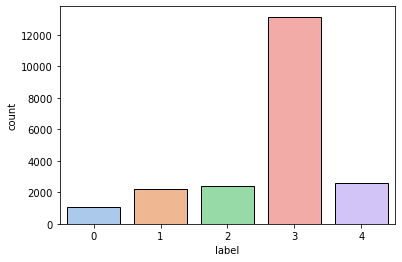

In [6]:
sns.countplot(train_labels.label, edgecolor = 'black',
              palette = sns.color_palette("pastel", 5))
plt.show()

In [7]:
sample = train_labels[train_labels.label == 3].sample(1)
print(train_labels[train_labels.label == 3])
image = cv2.imread(os.path.join(WORK_DIR, "train_images", sample.iloc[0,0]))


             image_id  label
1      1000201771.jpg      3
4      1000812911.jpg      3
5      1000837476.jpg      3
9      1001742395.jpg      3
10     1001749118.jpg      3
...               ...    ...
21386   997485103.jpg      3
21387   997651546.jpg      3
21388   997857988.jpg      3
21392   999068805.jpg      3
21393   999329392.jpg      3

[13158 rows x 2 columns]


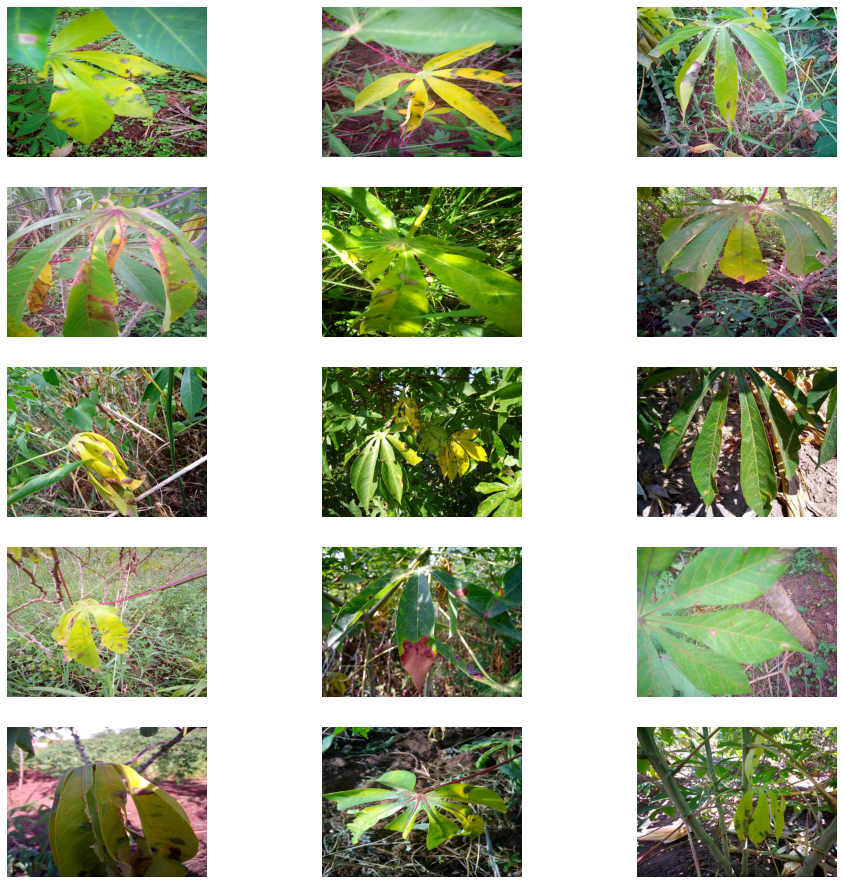

In [8]:
sample = train_labels[train_labels.label == 0].sample(15)
plt.figure(figsize=(16, 16))
for ind, (image_id, label) in enumerate(zip(sample.image_id, sample.label)):
    plt.subplot(5, 3, ind + 1)
    image = cv2.imread(os.path.join(WORK_DIR, "train_images", image_id))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image)
    plt.axis("off")
    
plt.show()

In [18]:
BATCH_SIZE = 16
STEPS_PER_EPOCH = len(train_labels)*0.8 / BATCH_SIZE
VALIDATION_STEPS = len(train_labels)*0.2 / BATCH_SIZE
EPOCHS = 10
TARGET_SIZE = 224

train_labels.label = train_labels.label.astype('str')
print(type(train_labels.label))


train_gen = ImageDataGenerator(validation_split = 0.2,
                                     preprocessing_function = None,
                                     zoom_range = 0.2,
                                     cval = 0.2,
                                     horizontal_flip = True,
                                     vertical_flip = True,
                                     fill_mode = 'nearest',
                                     shear_range = 0.2,
                                     height_shift_range = 0.2,
                                     width_shift_range = 0.2, 
                                     rescale=1.0/255.0) 

valid_gen = ImageDataGenerator(validation_split=0.2, rescale=1.0/255.0) 

train_it = train_gen.flow_from_dataframe(train_labels,
                         directory = os.path.join(WORK_DIR, "train_images"),
                         subset = "training",
                         x_col = "image_id",
                         y_col = "label",
                         target_size = (TARGET_SIZE, TARGET_SIZE),
                         batch_size = BATCH_SIZE,
                         class_mode = "sparse")
print(train_it)

valid_it = valid_gen.flow_from_dataframe(train_labels,
                         directory = os.path.join(WORK_DIR, "train_images"),
                         subset = "validation",
                         x_col = "image_id",
                         y_col = "label",
                         target_size = (TARGET_SIZE, TARGET_SIZE),
                         batch_size = BATCH_SIZE,
                         class_mode = "sparse")


<class 'pandas.core.series.Series'>
Found 17118 validated image filenames belonging to 5 classes.
Found 4279 validated image filenames belonging to 5 classes.


In [19]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function
from __future__ import unicode_literals

import os
import sys
import time
import glob

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import PIL
import imageio
from IPython import display

import tensorflow as tf
from tensorflow.keras import layers

from shutil import copyfile

# copy our file into the working directory (make sure it has .py suffix)
#copyfile(src = "../input/auxiliary-javad/image_utils.py", dst = "../working/image_utils.py")
#copyfile(src = "../input/axilury/ops.py", dst = "../working/ops.py")



#sys.path.append(os.path.dirname(os.path.abspath('.')))

#from image_utils import *
#from ops import *

#os.environ["CUDA_VISIBLE_DEVICES"]="0"


In [37]:
print(len(train_it))

1070


In [11]:
#A=np.concatenate((train_it[0][0],train_it[1][0]),axis=0)
#B=np.concatenate((train_it[0][1],train_it[1][1]),axis=0)
#for i in range(3):
    #A = np.concatenate((A, train_it[i+2][0]),axis=0)
    #B = np.concatenate((B, train_it[i+2][1]),axis=0)
    #print(A.shape)
    #print(B.shape)

#A_prime=np.concatenate((valid_it[0][0],valid_it[1][0]),axis=0)
#B_prime=np.concatenate((valid_it[0][1],valid_it[1][1]),axis=0)
#for i in range(3):
    #A_prime = np.concatenate((A_prime, train_it[i+2][0]),axis=0)
    #B_prime= np.concatenate((B_prime, train_it[i+2][1]),axis=0)
    #print(A_prime.shape)
    #print(B_prime.shape)
    
#del train_it  



(48, 224, 224, 3)
(48,)
(64, 224, 224, 3)
(64,)
(80, 224, 224, 3)
(80,)
(48, 224, 224, 3)
(48,)
(64, 224, 224, 3)
(64,)
(80, 224, 224, 3)
(80,)


In [20]:
#del valid_it
model_name = 'cgan'
train_dir = os.path.join('train', model_name, 'exp1')
max_epochs = 50
save_model_epochs = 10
print_steps = 100
save_images_epochs = 10
batch_size = 16 #16
learning_rate_D = 1e-4
learning_rate_G = 1e-3
k = 1 # the number of step of learning D before learning G (Not used in this code)
num_classes = 5# number of classes for cassava
num_examples_to_generate = num_classes
noise_dim = 100


In [21]:
def convert_shape_and_type_for_labels(x,y):
    y = tf.one_hot(y, depth=num_classes)
    y = tf.reshape(y, shape=[1, 1, num_classes])
    y = tf.cast(y, dtype = tf.float32)
    return x,y

In [ ]:
#N = len(A)
#train_images = (A - 127.5) / 127.5 
#train_images=A

In [ ]:
#del A
#train_labels=B.astype(int)
#train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
#train_dataset = train_dataset.shuffle(buffer_size=N)
#print(train_dataset)

#del train_images

In [ ]:
#tf.random.set_seed(219)
# for train
#train_images=tf.reshape(train_images, shape=[3200,224,224,1])

#train_dataset = train_dataset.map(convert_shape_and_type_for_labels)
#train_dataset = train_dataset.batch(batch_size=batch_size, drop_remainder=True)
#print(train_dataset)



In [22]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function
from __future__ import unicode_literals

import os
import glob

import numpy as np
import matplotlib.pyplot as plt

import PIL
import imageio


#num_examples_to_generate = 100
checkpoint_dir = './train'


def print_or_save_sample_images(sample_images, max_print_size=num_examples_to_generate,
                                is_square=False, is_save=False, epoch=None,
                                checkpoint_dir=checkpoint_dir):
  available_print_size = list(range(1, num_examples_to_generate+1))
  assert max_print_size in available_print_size
  if len(sample_images.shape) == 2:
    size = int(np.sqrt(sample_images.shape[1]))
    channel = 1
  elif len(sample_images.shape) > 2:
    size = sample_images.shape[1]
    channel = sample_images.shape[3]
  else:
    ValueError('Not valid a shape of sample_images')
  
  if not is_square:
    print_images = sample_images[:max_print_size, ...]
    print_images = print_images.reshape([max_print_size, size, size, channel])
    print_images = print_images.swapaxes(0, 1)
    print_images = print_images.reshape([size, max_print_size * size, channel])
    if channel == 1:
      print_images = np.squeeze(print_images, axis=-1)

    fig = plt.figure(figsize=(max_print_size, 1))
    plt.imshow(print_images * 0.5 + 0.5)#, cmap='gray')
    plt.axis('off')
    
  else:
    num_columns = int(np.sqrt(max_print_size))
    max_print_size = int(num_columns**2)
    print_images = sample_images[:max_print_size, ...]
    print_images = print_images.reshape([max_print_size, size, size, channel])
    print_images = print_images.swapaxes(0, 1)
    print_images = print_images.reshape([size, max_print_size * size, channel])
    print_images = [print_images[:,i*size*num_columns:(i+1)*size*num_columns] for i in range(num_columns)]
    print_images = np.concatenate(tuple(print_images), axis=0)
    if channel == 1:
      print_images = np.squeeze(print_images, axis=-1)
    
    fig = plt.figure(figsize=(num_columns, num_columns))
    plt.subplots_adjust(left=0.0, right=1.0, top=1.0, bottom=0.0)
    plt.imshow(print_images * 0.5 + 0.5)#, cmap='gray')
    plt.axis('off')
    
  if is_save and epoch is not None:
    filepath = os.path.join(checkpoint_dir, 'image_at_epoch_{:04d}.png'.format(epoch))
    plt.savefig(filepath)
  else:
    plt.show()


def print_or_save_sample_images_two(sample_images1, sample_images2, max_print_size=num_examples_to_generate,
                                    is_square=False, is_save=False, epoch=None,
                                    checkpoint_dir=checkpoint_dir):
  available_print_size = list(range(1, num_examples_to_generate+1))
  assert max_print_size in available_print_size

  if len(sample_images1.shape) == 2:
    size = int(np.sqrt(sample_images1.shape[1]))
    channel = 1
  elif len(sample_images1.shape) > 2:
    size = sample_images1.shape[1]
    channel = sample_images1.shape[3]
  else:
    ValueError('Not valid a shape of sample_images')
  
  if not is_square:
    print_images1 = sample_images1[:max_print_size, ...]
    print_images1 = print_images1.reshape([max_print_size, size, size, channel])
    print_images1 = print_images1.swapaxes(0, 1)
    print_images1 = print_images1.reshape([size, max_print_size * size, channel])

    print_images2 = sample_images2[:max_print_size, ...]
    print_images2 = print_images2.reshape([max_print_size, size, size, channel])
    print_images2 = print_images2.swapaxes(0, 1)
    print_images2 = print_images2.reshape([size, max_print_size * size, channel])

    print_images = np.concatenate((print_images1, print_images2), axis=0)
    if channel == 1:
      print_images = np.squeeze(print_images, axis=-1)
     
    plt.figure(figsize=(max_print_size, 2))
    plt.axis('off')
    plt.imshow(print_images)#, cmap='gray')
  else:
    print('This function is supported by `is_square=False` mode.')

  if is_save and epoch is not None:
    filepath = os.path.join(checkpoint_dir, 'image_at_epoch_{:04d}.png'.format(epoch))
    plt.savefig(filepath)
  else:
    plt.show()


def print_or_save_sample_images_pix2pix(x, y, z, model_name, name=None,
                                        is_save=False, epoch=None, checkpoint_dir=checkpoint_dir):
  #plt.figure(figsize=(15, 5))
  plt.figure(figsize=(12, 4))
  plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)

  display_list = [x[0], y[0], z[0]]
  assert model_name in ['pix2pix', 'cyclegan', 'stargan']
  if model_name == 'pix2pix':
    title = ['Input Image', 'Ground Truth', 'Predicted Image']
  elif model_name == 'cyclegan':
    assert name in ['X2Y2X', 'Y2X2Y']
    if name == 'X2Y2X':
      title = ['X domain', 'X -> Y', 'X -> Y -> X']
    else:
      title = ['Y domain', 'Y -> X', 'Y -> X -> Y']
  else:
    title = ['original domain', 'original -> target', 'original -> target -> original']

  for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.title(title[i])
    # getting the pixel values between [0, 1] to plot it.
    plt.imshow(display_list[i] * 0.5 + 0.5)
    plt.axis('off')

  if is_save and epoch is not None:
    if name is not None:
      filename = 'image_' + name + '_at_epoch_'
    else:
      filename = 'image_at_epoch_'
    filepath = os.path.join(checkpoint_dir, filename + '{:04d}.png'.format(epoch))
    plt.savefig(filepath)
  else:
    plt.show()


def display_image(epoch_no, name=None, checkpoint_dir=checkpoint_dir):
  if name is not None:
    filename = 'image_' + name + '_at_epoch_'
  else:
    filename = 'image_at_epoch_'
  filepath = os.path.join(checkpoint_dir, filename + '{:04d}.png'.format(epoch_no))
  return PIL.Image.open(filepath)


def generate_gif(gif_filename, checkpoint_dir=checkpoint_dir):
  with imageio.get_writer(gif_filename, mode='I') as writer:
    filenames = glob.glob(os.path.join(checkpoint_dir, 'image*.png'))
    filenames = sorted(filenames)
    last = -1
    for i, filename in enumerate(filenames):
      frame = 2*(i**0.5)
      if round(frame) > round(last):
        last = frame
      else:
        continue
      image = imageio.imread(filename)
      writer.append_data(image)
    image = imageio.imread(filename)
    writer.append_data(image)
  
  # this is a hack to display the gif inside the notebook
  filename_to_copy = gif_filename + '.png'
  print('cp {} {}'.format(gif_filename, filename_to_copy))
  os.system('cp {} {}'.format(gif_filename, filename_to_copy))

In [23]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function

import tensorflow as tf
from tensorflow.keras import layers



class Conv(tf.keras.Model):
  def __init__(self, filters, kernel_size, strides, padding='same',
               activation='relu', apply_batchnorm=True, norm_momentum=0.9, norm_epsilon=1e-5,
               leaky_relu_alpha=0.2, name='conv_layer'):
    super(Conv, self).__init__(name=name)
    assert activation in ['relu', 'leaky_relu', 'none']
    self.activation = activation
    self.apply_batchnorm = apply_batchnorm
    self.leaky_relu_alpha = leaky_relu_alpha

    self.conv = layers.Conv2D(filters=filters,
                              kernel_size=(kernel_size, kernel_size),
                              strides=strides,
                              padding=padding,
                              kernel_initializer=tf.random_normal_initializer(0., 0.02),
                              use_bias=not self.apply_batchnorm)
    if self.apply_batchnorm:
      self.batchnorm = layers.BatchNormalization(momentum=norm_momentum,
                                                 epsilon=norm_epsilon)

  def call(self, x, training=True):
    # convolution
    x = self.conv(x)

    # batchnorm
    if self.apply_batchnorm:
      x = self.batchnorm(x, training=training)

    # activation
    if self.activation == 'relu':
      x = tf.nn.relu(x)
    elif self.activation == 'leaky_relu':
      x = tf.nn.leaky_relu(x, alpha=self.leaky_relu_alpha)
    else:
      pass

    return x



class ConvTranspose(tf.keras.Model):
  def __init__(self, filters, kernel_size, strides=2, padding='same',
               activation='relu', apply_batchnorm=True, norm_momentum=0.9, norm_epsilon=1e-5,
               name='conv_transpose_layer'):
    super(ConvTranspose, self).__init__(name=name)
    assert activation in ['relu', 'sigmoid', 'tanh', 'none']
    self.activation = activation
    self.apply_batchnorm = apply_batchnorm

    self.up_conv = layers.Conv2DTranspose(filters=filters,
                                          kernel_size=(kernel_size, kernel_size),
                                          strides=strides,
                                          padding=padding,
                                          kernel_initializer=tf.random_normal_initializer(0., 0.02),
                                          use_bias=not self.apply_batchnorm)
    if self.apply_batchnorm:
      self.batchnorm = layers.BatchNormalization(momentum=norm_momentum,
                                                 epsilon=norm_epsilon)

  def call(self, x, training=True):
    # conv transpose
    x = self.up_conv(x)
    
    # batchnorm
    if self.apply_batchnorm:
      x = self.batchnorm(x, training=training)
      
    # activation
    if self.activation == 'relu':
      x = tf.nn.relu(x)
    elif self.activation == 'sigmoid':
      x = tf.nn.sigmoid(x)
    elif self.activation == 'tanh':
      x = tf.nn.tanh(x)
    else:
      pass
    
    return x



class Dense(tf.keras.Model):
  def __init__(self, units, activation='relu', apply_batchnorm=True, norm_momentum=0.9, norm_epsilon=1e-5,
               leaky_relu_alpha=0.2, name='dense_layer'):
    super(Dense, self).__init__(name=name)
    assert activation in ['relu', 'leaky_relu', 'none']
    self.activation = activation
    self.apply_batchnorm = apply_batchnorm
    self.leaky_relu_alpha = leaky_relu_alpha

    self.dense = layers.Dense(units=units,
                              kernel_initializer=tf.random_normal_initializer(0., 0.02),
                              use_bias=not self.apply_batchnorm)
    if self.apply_batchnorm:
      self.batchnorm = layers.BatchNormalization(momentum=norm_momentum,
                                                 epsilon=norm_epsilon)

  def call(self, x, training=True):
    # dense
    x = self.dense(x)

    # batchnorm
    if self.apply_batchnorm:
      x = self.batchnorm(x, training=training)

    # activation
    if self.activation == 'relu':
      x = tf.nn.relu(x)
    elif self.activation == 'leaky_relu':
      x = tf.nn.leaky_relu(x, alpha=self.leaky_relu_alpha)
    else:
      pass

    return x


In [24]:


class Generator(tf.keras.Model):
  """Build a generator that maps latent space to real space given conditions.
    G(z, c): (z, c) -> x
  """
  def __init__(self):
    super(Generator, self).__init__()
    #self.input_layer = tf.keras.layers.Dense(units = 105)
    #self.dense_1 = tf.keras.layers.Dense(units = 1024)
    #self.leaky_1 =  tf.keras.layers.LeakyReLU(alpha = 0.01)
    #self.dense_2 = tf.keras.layers.Dense(units = 512)
    #self.leaky_2 = tf.keras.layers.LeakyReLU(alpha = 0.01)
    #self.dense_3 = tf.keras.layers.Dense(units = 512)
    #self.leaky_3 = tf.keras.layers.LeakyReLU(alpha = 0.01)
    #self.output_layer = tf.keras.layers.Dense(units=28*28*3, activation = "tanh")
    #self.conv1 = ConvTranspose(1024, 3, padding='valid')
    #self.conv2 = ConvTranspose(512, 3, padding='valid')
    #self.conv3 = ConvTranspose(64, 4)
    #self.conv4 = ConvTranspose(3, 4, apply_batchnorm=False, activation='tanh')
    self.conv1 = ConvTranspose(128, 3, padding='valid')
    self.conv2 = ConvTranspose(64, 3, padding='valid')
    self.conv3 = ConvTranspose(32, 4)
    self.conv4 = ConvTranspose(32, 4)
    self.conv5 = ConvTranspose(16, 4)
    self.conv6 = ConvTranspose(16, 4)
    self.conv7 = ConvTranspose(3, 4, apply_batchnorm=False, activation='tanh')
    
  def call(self, noise_inputs, conditions, training=True):
    """Run the model."""
    # noise_inputs: [1, 1, 100]
    # conditions: [1, 1, 5] (for MNIST)
    # inputs = 1 x 1 x (100 + 5) dim
    #inputs = tf.concat([noise_inputs, conditions], axis=3)
    #conv1 = self.conv1(inputs, training=training)           # conv1: [3, 3, 256]
    #conv2 = self.conv2(conv1, training=training)            # conv2: [7, 7, 128]
    #conv3 = self.conv3(conv2, training=training)  # conv3: [14, 14, 64]
    #inputs = tf.concat([noise_inputs, conditions], axis=2)
    #x = self.input_layer(inputs)
    #x = self.dense_1(x)
    #x = self.leaky_1(x)
    #x = self.dense_2(x)
    #x = self.leaky_2(x)
    #x = self.dense_3(x)
    #x = self.leaky_3(x)
    #generated_images = self.output_layer(x) # generated_images: [28, 28, 1]
    
    inputs = tf.concat([noise_inputs, conditions], axis=3)
    conv1 = self.conv1(inputs, training=training)           # conv1: [3, 3, 256]
    conv2 = self.conv2(conv1, training=training)            # conv2: [7, 7, 128]
    conv3 = self.conv3(conv2, training=training)            # conv3: [14, 14, 64]
    conv4 = self.conv4(conv3, training=training) 
    conv5 = self.conv5(conv4, training=training) 
    conv6 = self.conv6(conv5, training=training) 

    generated_images = self.conv7(conv6, training=training) # generated_images: [28, 28, 1]
    
    return generated_images
    #return tf.reshape(generated_images, shape=[28, 28, 3])


class Discriminator(tf.keras.Model):
  """Build a discriminator that discriminate tuple (x, c) whether real or fake.
    D(x, c): (x, c) -> [0, 1]
  """
  def __init__(self):
    super(Discriminator, self).__init__()
    #self.input_layer = tf.keras.layers.Dense(units = 28*28*8)
    #self.dense_1 = tf.keras.layers.Dense(units = 2048)
    #self.leaky_1 = tf.keras.layers.LeakyReLU(alpha = 0.01)
    #self.dense_2 = tf.keras.layers.Dense(units = 1280)
    #self.leaky_2 = tf.keras.layers.LeakyReLU(alpha = 0.01)
    #self.dense_3 = tf.keras.layers.Dense(units = 128)
    #self.leaky_3 = tf.keras.layers.LeakyReLU(alpha = 0.01)    
    #self.logits = tf.keras.layers.Dense(units = 1)  # This neuron tells us if the input is fake or real
    #self.conv1 = Conv(64, 4, 2, apply_batchnorm=False, activation='leaky_relu')
    #self.conv2 = Conv(128, 4, 2, activation='leaky_relu')
    #self.conv3 = Conv(256, 3, 2, padding='valid', activation='leaky_relu')
    #self.conv4 = Conv(1, 3, 1, padding='valid', apply_batchnorm=False, activation='none')
    self.conv1 = Conv(64, 4, 2, apply_batchnorm=False, activation='leaky_relu')
    self.conv2 = Conv(128, 4, 2, activation='leaky_relu')
    self.conv3 = Conv(64, 4, 2, activation='leaky_relu')
    self.conv4 = Conv(32, 4, 2, activation='leaky_relu')
    self.conv5 = Conv(32, 4, 2, activation='leaky_relu')
    self.conv6 = Conv(16, 3, 2, padding='valid', activation='leaky_relu')
    self.conv7 = Conv(1, 3, 1, padding='valid', apply_batchnorm=False, activation='none')

  def call(self, image_inputs, conditions, training=True):
    """Run the model."""
    # image_inputs: [28, 28, 1]
    # conditions: 5 dim (for MNIST)
    # inputs: [28, 28, (3 + 5)]
    #inputs = tf.concat([image_inputs,
                        #conditions * tf.ones([28, 28,num_classes])], axis=2)
    #conv1 = self.conv1(inputs)                            # conv1: [14, 14, 64]
    #conv2 = self.conv2(conv1)                             # conv2: [7, 7, 128]
    #conv3 = self.conv3(conv2)                             # conv3: [3, 3, 256]
    #conv4 = self.conv4(conv3)                             # conv4: [1, 1, 1]
    #discriminator_logits = tf.squeeze(conv4, axis=[1, 2]) # discriminator_logits: [1,]
    #x = self.input_layer(tf.reshape(inputs, shape=[1, 28*28*8]))
    #x = self.dense_1(x)
    #x = self.leaky_1(x)
    #x = self.leaky_2(x)
    #x = self.leaky_3(x)
    #x = self.leaky_3(x)
    #x = self.logits(x)
    #return x
    """Run the model."""
    # image_inputs: [28, 28, 1]
    # conditions: 10 dim (for MNIST)
    # inputs: [28, 28, (1 + 10)]
    inputs = tf.concat([image_inputs,
                        conditions * tf.ones([image_inputs.shape[0],
                                              224, 224,
                                              num_classes])], axis=3)
    conv1 = self.conv1(inputs)                            # conv1: [14, 14, 64]
    conv2 = self.conv2(conv1)                             # conv2: [7, 7, 128]
    conv3 = self.conv3(conv2)                             # conv3: [3, 3, 256]
    conv4 = self.conv4(conv3)  
    conv5 = self.conv5(conv4) 
    # conv4: [1, 1, 1]
    conv6 = self.conv6(conv5) 
    conv7 = self.conv7(conv6) 
    discriminator_logits = tf.squeeze(conv7, axis=[1, 2]) # discriminator_logits: [1,]
    
    return discriminator_logits
    
   # return discriminator_logits

In [25]:
generator = Generator()
discriminator = Discriminator()

(1, 224, 224, 3)
tf.Tensor([[0.07749924]], shape=(1, 1), dtype=float32)
tf.Tensor([[[[1. 0. 0. 0. 0.]]]], shape=(1, 1, 1, 5), dtype=float32)


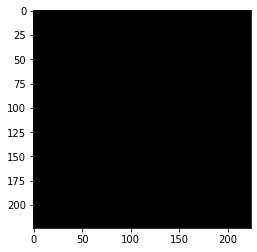

In [26]:
noise_dim=100
noise = tf.random.normal([ 1, 1,1, noise_dim])
condition = tf.one_hot(tf.random.uniform(shape=[], minval=0, maxval=5, dtype=tf.int32), depth=num_classes)
condition = tf.reshape(condition, shape=[ 1, 1,1, num_classes])
generated_image = generator(noise, condition, training=False)
print(generated_image.shape)
plt.imshow(generated_image[0, :, :, :])

decision = discriminator(generated_image, condition)
print(decision)

# use logits for consistency with previous code I made
# `tf.losses` and `tf.keras.losses` are the same API (alias)
bce = tf.losses.BinaryCrossentropy(from_logits=True)

print(condition)



In [27]:

def GANLoss(logits, is_real=True):
    if is_real:
        labels = tf.ones_like(logits)
    else:
        labels = tf.zeros_like(logits)
    return bce(labels, logits)

def discriminator_loss(real_logits, fake_logits):
  # losses of real with label "1"
  real_loss = GANLoss(logits=real_logits, is_real=True)
  # losses of fake with label "0"
  fake_loss = GANLoss(logits=fake_logits, is_real=False)
  
  return real_loss + fake_loss

def generator_loss(fake_logits):
  # losses of Generator with label "1" that used to fool the Discriminator
  return GANLoss(logits=fake_logits, is_real=True)

In [28]:
#discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate_D, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.RMSprop(learning_rate_D)
generator_optimizer = tf.keras.optimizers.Adam(learning_rate_G, beta_1=0.5)

In [29]:
checkpoint_dir = train_dir
if not tf.io.gfile.exists(checkpoint_dir):
    tf.io.gfile.makedirs(checkpoint_dir)
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

In [62]:
# keeping the random vector constant for generation (prediction) so
# it will be easier to see the improvement of the gan.
# To visualize progress in the animated GIF
num_examples_to_generate=5
const_random_vector_for_saving = tf.random.uniform([num_examples_to_generate, 1, 1, noise_dim],
                                                   minval=-1.0, maxval=1.0)


In [31]:
# Notice the use of `tf.function`
# This annotation causes the function to be "compiled".
@tf.function
def train_step(images, labels):
    
    noise = tf.random.uniform([batch_size, 1, 1, noise_dim], minval=-1.0, maxval=1.0)
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, labels, training=True)
        real_logits = discriminator(images, labels, training=True)
        fake_logits = discriminator(generated_images, labels, training=True)
        gen_loss = generator_loss(fake_logits)
        disc_loss = discriminator_loss(real_logits, fake_logits)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))
    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    return gen_loss, disc_loss

In [ ]:
print(type(train_dataset))

Start Training.
Epochs: 0.19 global_step: 100 loss_D: 1.32 loss_G: 0.722 (1275.76 examples/sec; 0.013 sec/batch)
Epochs: 0.37 global_step: 200 loss_D: 1.3 loss_G: 0.706 (1280.09 examples/sec; 0.012 sec/batch)
Epochs: 0.56 global_step: 300 loss_D: 1.33 loss_G: 0.762 (1292.00 examples/sec; 0.012 sec/batch)
Epochs: 0.75 global_step: 400 loss_D: 1.3 loss_G: 0.791 (1254.54 examples/sec; 0.013 sec/batch)
Epochs: 0.93 global_step: 500 loss_D: 1.16 loss_G: 0.831 (1237.58 examples/sec; 0.013 sec/batch)
Epochs: 1.19 global_step: 600 loss_D: 1.32 loss_G: 0.68 (1266.40 examples/sec; 0.013 sec/batch)
Epochs: 1.37 global_step: 700 loss_D: 1.4 loss_G: 0.693 (1223.54 examples/sec; 0.013 sec/batch)
Epochs: 1.56 global_step: 800 loss_D: 1.43 loss_G: 0.7 (1240.60 examples/sec; 0.013 sec/batch)
Epochs: 1.75 global_step: 900 loss_D: 1.17 loss_G: 0.917 (1220.54 examples/sec; 0.013 sec/batch)
Epochs: 1.93 global_step: 1000 loss_D: 1.35 loss_G: 0.727 (1225.37 examples/sec; 0.013 sec/batch)
Epochs: 2.19 global

Epochs: 16.93 global_step: 8500 loss_D: 1.23 loss_G: 0.945 (834.06 examples/sec; 0.019 sec/batch)
Epochs: 17.19 global_step: 8600 loss_D: 1.24 loss_G: 0.888 (1228.34 examples/sec; 0.013 sec/batch)
Epochs: 17.37 global_step: 8700 loss_D: 1.11 loss_G: 0.889 (1182.06 examples/sec; 0.014 sec/batch)
Epochs: 17.56 global_step: 8800 loss_D: 1.08 loss_G: 1.11 (1227.12 examples/sec; 0.013 sec/batch)
Epochs: 17.75 global_step: 8900 loss_D: 1.48 loss_G: 0.461 (1171.29 examples/sec; 0.014 sec/batch)
Epochs: 17.93 global_step: 9000 loss_D: 1.57 loss_G: 1.24 (980.01 examples/sec; 0.016 sec/batch)
Epochs: 18.19 global_step: 9100 loss_D: 1.47 loss_G: 0.791 (1216.27 examples/sec; 0.013 sec/batch)
Epochs: 18.37 global_step: 9200 loss_D: 1.36 loss_G: 0.541 (967.39 examples/sec; 0.017 sec/batch)
Epochs: 18.56 global_step: 9300 loss_D: 1.24 loss_G: 0.834 (1247.26 examples/sec; 0.013 sec/batch)
Epochs: 18.75 global_step: 9400 loss_D: 1.46 loss_G: 0.509 (1190.38 examples/sec; 0.013 sec/batch)
Epochs: 18.93 g

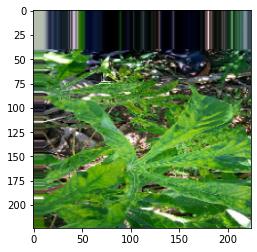

In [38]:
print('Start Training.')
#num_batches_per_epoch = int(N / batch_size)
num_batches_per_epoch=535
global_step = tf.Variable(0, trainable=False)
sample_condition = tf.eye(num_classes)
sample_condition = tf.reshape(sample_condition, [-1, 1, 1, num_classes])
max_epochs=20

for epoch in range(max_epochs):
    #for step, (images, labels) in enumerate(train_dataset):
    for i in range(500):
        
        images=train_it[i][0]
        y=train_it[i][1]
        labels= tf.one_hot(y, depth=num_classes)
        labels = tf.reshape(labels, shape=[16,1, 1, num_classes])
        labels = tf.cast(labels, dtype = tf.float32)
        plt.imshow(images[0, :, :, :])
        start_time = time.time()
        gen_loss, disc_loss = train_step(images, labels)
        global_step.assign_add(1)
        if global_step.numpy() % print_steps == 0:
            epochs = epoch + i / float(num_batches_per_epoch)
            duration = time.time() - start_time
            examples_per_sec = batch_size / float(duration)
            #display.clear_output(wait=True)
            print("Epochs: {:.2f} global_step: {} loss_D: {:.3g} loss_G: {:.3g} ({:.2f} examples/sec; {:.3f} sec/batch)".format(
            epochs, global_step.numpy(), disc_loss, gen_loss, examples_per_sec, duration))
            noise = tf.random.uniform([num_examples_to_generate, 1, 1, noise_dim], minval=-1.0, maxval=1.0)
            sample_images = generator(noise, sample_condition, training=False)
           # print_or_save_sample_images(sample_images.numpy(), num_examples_to_generate)

   # if (epoch + 1) % save_images_epochs == 0:
        #display.clear_output(wait=True)
       # print("This images are saved at {} epoch".format(epoch+1))
       # sample_images = generator(const_random_vector_for_saving, sample_condition, training=False)
       # print_or_save_sample_images(sample_images.numpy(), num_examples_to_generate,
                              ##  is_save=True, epoch=epoch+1,
                                #checkpoint_dir=checkpoint_dir)
    #saving (checkpoint) the model every save_epochs
   # if (epoch + 1) % save_model_epochs == 0:
        #checkpoint.save(file_prefix=checkpoint_prefix)
print('Training Done.')

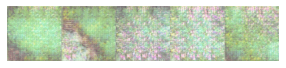

In [64]:

# generating after the final epoch
sample_condition = tf.eye(num_classes)
sample_condition = tf.reshape(sample_condition, [-1, 1, 1, num_classes])
display.clear_output(wait=True)
sample_images = generator(const_random_vector_for_saving, sample_condition, training=False)

print_or_save_sample_images(sample_images.numpy(), num_examples_to_generate,
                            is_save=True, epoch=epoch+1,
                            checkpoint_dir=checkpoint_dir)

<class 'tensorflow.python.framework.ops.EagerTensor'>
(16, 224, 224, 3)


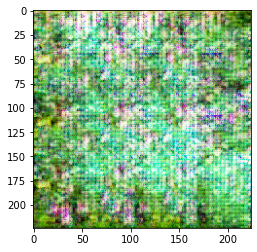

In [76]:
noise_dim=100
noise = tf.random.normal([ 16, 1,1, noise_dim])
print(type(condition))
condition = tf.one_hot(tf.random.uniform(shape=[16], minval=0, maxval=5, dtype=tf.int32), depth=num_classes)
condition = tf.reshape(condition, shape=[ 16, 1,1, num_classes])
generated_image = generator(noise, condition, training=False)
print(generated_image.shape)
plt.imshow(generated_image[0, :, :, :])

In [40]:
dataset_name='cassava'
# restoring the latest checkpoint in checkpoint_dir
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))
filename = model_name + '_' + dataset_name + '.gif'
generate_gif(filename, checkpoint_dir)

cp cgan_cassava.gif cgan_cassava.gif.png


In [41]:
def create_model():   
    # Good resource 
    # https://androidkt.com/how-to-use-vgg-model-in-tensorflow-keras/
    
    vgg16_model = VGG16(include_top=False, input_shape=(TARGET_SIZE, TARGET_SIZE, 3), weights='imagenet' )
                  
    vgg16_model.trainable=False                
    
    global_average_layer = tf.keras.layers.GlobalAveragePooling2D()              
                  
    prediction_layer = tf.keras.layers.Dense(5, activation='softmax')
    
    model = tf.keras.Sequential([vgg16_model,
                                 global_average_layer,
                                 prediction_layer
                                 ])
    
    
    
    opt = Adam(lr = 0.0001)
    
    # The following resource was very helpful to 
    # treat the imbalanced class problem. 
    # https://medium.com/@markryan_69718/what-to-do-when-the-labels-are-skewed-tackling-the-accuracy-paradox-7b72bd4a9ccc
        
    
    
    model.compile(optimizer = opt ,
                  loss = "sparse_categorical_crossentropy",
                  metrics = ["acc"], 
                  weighted_metrics=["accuracy"]
                 )
    return model

In [42]:
model_base = create_model()
model_base.summary()

58892288/58889256 [==============================] - 0s 0us/step
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
vgg16 (Functional)           (None, 7, 7, 512)         14714688  
_________________________________________________________________
global_average_pooling2d (Gl (None, 512)               0         
_________________________________________________________________
dense (Dense)                (None, 5)                 2565      
Total params: 14,717,253
Trainable params: 2,565
Non-trainable params: 14,714,688
_________________________________________________________________


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

optimizer = keras.optimizers.SGD(learning_rate=1e-3)
# Instantiate a loss function.
loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# Prepare the training dataset.
batch_size = 16

train_acc_metric = keras.metrics.SparseCategoricalAccuracy()

epochs = 20
for epoch in range(epochs):
    print("\nStart of epoch %d" % (epoch,))

    # Iterate over the batches of the dataset.
    for i in range(200):
        y_batch_train=[3,3,3,3,3,3,3,3,3,4,4,2,2,1,1,0]
        y_batch_train=tf.random.shuffle(y_batch_train)
        noise_dim=100
        noise = tf.random.normal([ 16, 1,1, noise_dim])
        condition = tf.one_hot(y_batch_train, depth=num_classes)
        condition = tf.reshape(condition, shape=[ 16, 1,1, num_classes])
        generated_image = generator(noise, condition, training=False)
        x_batch_train=generated_image

        # Open a GradientTape to record the operations run
        # during the forward pass, which enables auto-differentiation.
        with tf.GradientTape() as tape:

            # Run the forward pass of the layer.
            # The operations that the layer applies
            # to its inputs are going to be recorded
            # on the GradientTape.
            logits = model_base(x_batch_train, training=True)  # Logits for this minibatch

            # Compute the loss value for this minibatch.
            loss_value = loss_fn(y_batch_train, logits)

        # Use the gradient tape to automatically retrieve
        # the gradients of the trainable variables with respect to the loss.
        grads = tape.gradient(loss_value, model_base.trainable_weights)
        train_acc_metric.update_state(y_batch_train, logits)
        # Run one step of gradient descent by updating
        # the value of the variables to minimize the loss.
        optimizer.apply_gradients(zip(grads, model_base.trainable_weights))
        

        # Log every 200 batches.
        if i % 99 == 0:
            print(
                "Training loss (for one batch) at step %d: %.4f"
                % (i, float(loss_value))
            )
            print("Seen so far: %s samples" % ((i + 1) * 16))
    train_acc = train_acc_metric.result()
    print("Training acc over epoch: %.4f" % (float(train_acc),))

    # Reset training metrics at the end of each epoch
    train_acc_metric.reset_states()


Start of epoch 0
Training loss (for one batch) at step 0: 2.1140
Seen so far: 16 samples
Training loss (for one batch) at step 99: 1.2719
Seen so far: 1600 samples
Training loss (for one batch) at step 198: 1.2917
Seen so far: 3184 samples
Training acc over epoch: 0.5244

Start of epoch 1
Training loss (for one batch) at step 0: 1.2816
Seen so far: 16 samples
Training loss (for one batch) at step 99: 1.2878
Seen so far: 1600 samples
Training loss (for one batch) at step 198: 1.2697
Seen so far: 3184 samples
Training acc over epoch: 0.5625

Start of epoch 2
Training loss (for one batch) at step 0: 1.2759
Seen so far: 16 samples
Training loss (for one batch) at step 99: 1.2945
Seen so far: 1600 samples
Training loss (for one batch) at step 198: 1.2833
Seen so far: 3184 samples
Training acc over epoch: 0.5625

Start of epoch 3
Training loss (for one batch) at step 0: 1.2714
Seen so far: 16 samples
Training loss (for one batch) at step 99: 1.2607
Seen so far: 1600 samples
Training loss (f

In [ ]:
model_base = create_model()
model_base.summary()

In [ ]:
epochs = 50
for epoch in range(epochs):
    print("\nStart of epoch %d" % (epoch,))

    # Iterate over the batches of the dataset.
    for i in range(200):
  
        x_batch_train=valid_it[i][0]
        y_batch_train=valid_it[i][1]

        # Open a GradientTape to record the operations run
        # during the forward pass, which enables auto-differentiation.
        with tf.GradientTape() as tape:

            # Run the forward pass of the layer.
            # The operations that the layer applies
            # to its inputs are going to be recorded
            # on the GradientTape.
            logits = model_base(x_batch_train, training=True)  # Logits for this minibatch

            # Compute the loss value for this minibatch.
            loss_value = loss_fn(y_batch_train, logits)

        # Use the gradient tape to automatically retrieve
        # the gradients of the trainable variables with respect to the loss.
        grads = tape.gradient(loss_value, model_base.trainable_weights)
        train_acc_metric.update_state(y_batch_train, logits)

        # Run one step of gradient descent by updating
        # the value of the variables to minimize the loss.
        optimizer.apply_gradients(zip(grads, model_base.trainable_weights))
        

        # Log every 200 batches.
        if i % 99 == 0:
            print(
                "Training loss (for one batch) at step %d: %.4f"
                % (i, float(loss_value))
            )
            print("Seen so far: %s samples" % ((i + 1) * 16))
    train_acc = train_acc_metric.result()
    print("Training acc over epoch: %.4f" % (float(train_acc),))

    # Reset training metrics at the end of each epoch
    train_acc_metric.reset_states()